# Instrucciones

* Puede ser citado a sustentación individual tras sospecha de fraude.
* Cualquier intento de fraude anulará el examen.
* Todos los puntos tienen el mismo peso.
* Envíe un archivo "nombrecompleto.py" con las soluciones del parcial antes de la hora indicada al correo johnathancalle@gmail.com

# Clases Base



In [ ]:
from collections import deque
from typing import Any, Optional, List

class BinaryNode:
    def __init__(self, value: Any):
        self.value = value
        self.left: Optional["BinaryNode"] = None
        self.right: Optional["BinaryNode"] = None

    def __repr__(self):
        return f"{self.value}"

class BinaryTree:
    def __init__(self):
        self.root: Optional[BinaryNode] = None

    def insert_by_level(self, values: List[Optional[Any]]) -> None:
        """
        Construye el árbol a partir de una lista por niveles.
        Usa None para representar nodos vacíos.
        Ejemplo:
            tree.insert_by_level([1, 2, 3, None, 5])
            Genera:
                  1
                 / \
                2   3
                 \
                  5
        """
        if not values:
            return

        # Crear el nodo raíz si el primer valor no es None
        if values[0] is None:
            self.root = None
            return

        self.root = BinaryNode(values[0])
        queue = deque([self.root])
        i = 1  # índice de la lista

        while queue and i < len(values):
            current = queue.popleft()

            # Hijo izquierdo
            if i < len(values):
                left_val = values[i]
                if left_val is not None:
                    current.left = BinaryNode(left_val)
                    queue.append(current.left)
                i += 1

            # Hijo derecho
            if i < len(values):
                right_val = values[i]
                if right_val is not None:
                    current.right = BinaryNode(right_val)
                    queue.append(current.right)
                i += 1

    def insert(self, parent: Any, value: Any) -> None:
      """
      Inserta 'value' como hijo izquierdo o derecho (el primero libre)
      del primer nodo cuyo valor sea 'parent', encontrado por DFS (preorden).
      Si el árbol está vacío y parent es None, 'value' pasa a ser la raíz.
      """
      new_node = BinaryNode(value)

      # Árbol vacío: permitir crear la raíz si parent es None
      if self.root is None:
        if parent is None:
          self.root = new_node
        else:
          print(f"⚠️ Árbol vacío y 'parent' distinto de None ('{parent}'). No se insertó '{value}'.")
        return

      # DFS recursivo para encontrar la primera ocurrencia de 'parent'
      def __dfs_insert(node: Optional[BinaryNode]) -> bool:
        if node is None:
          return False

        # Visita (preorden): primero el nodo actual
        if node.value == parent:
          if node.left is None:
            node.left = new_node
            return True
          if node.right is None:
            node.right = new_node
            return True
          # Ambos hijos ocupados: continuar buscando otra ocurrencia abajo

        # Luego subárbol izquierdo
        if __dfs_insert(node.left):
          return True
        # Luego subárbol derecho
        return __dfs_insert(node.right)

      if not __dfs_insert(self.root):
        print(f"⚠️ No se encontró el nodo con valor '{parent}'. No se insertó '{value}'.")

    def print(self, node=None, prefix="", is_left=True, flag=True):
        if flag:
            node = self.root
        if not node:
            print("Empty Tree")
            return
        if node.right:
            self.print(node.right, prefix + ("│   " if is_left else "    "), False, False)
        print(prefix + ("└── " if is_left else "┌── ") + str(node.value))
        if node.left:
            self.print(node.left, prefix + ("    " if is_left else "│   "), True, False)



class BinarySearchTree:
  def __init__(self):
    self.root: BinaryNode = None

  def insert(self, value: Any, current: BinaryNode = None) -> None:
    # Caso base: si el árbol está vacío, el nuevo valor será la raíz
    if self.root is None:
      self.root = BinaryNode(value)
      return

    # Si no se pasa un nodo actual, comenzamos desde la raíz
    if current is None:
      current = self.root

    # Insertar recursivamente en el subárbol correspondiente
    if value < current.value:
      if current.left is None:
        current.left = BinaryNode(value)
      else:
        self.insert(value, current.left)
    elif value > current.value:
      if current.right is None:
        current.right = BinaryNode(value)
      else:
        self.insert(value, current.right)
    # Si es igual, no se inserta (evita duplicados)
    else:
      return

  def print(self, node=None, prefix="", is_left=True, flag=True):
      if flag:
          node = self.root
      if not node:
          print("Empty Tree")
          return
      if node.right:
          self.print(node.right, prefix + ("│   " if is_left else "    "), False, False)
      print(prefix + ("└── " if is_left else "┌── ") + str(node.value))
      if node.left:
          self.print(node.left, prefix + ("    " if is_left else "│   "), True, False)

from typing import Any, Optional, List

class GeneralNode:
    def __init__(self, value: Any):
        self.value = value
        self.children: List["GeneralNode"] = []

    def __repr__(self):
        return f"{self.value}"


class GeneralTree:
    def __init__(self):
        self.root: Optional[GeneralNode] = None

    def insert(self, parent: Optional[Any], value: Any) -> None:
        """
        Inserta un nuevo nodo con 'value' como hijo del nodo cuyo valor es 'parent'.
        Si el árbol está vacío y parent es None, el nuevo nodo se convierte en la raíz.
        """
        new_node = GeneralNode(value)

        if self.root is None:
            if parent is None:
                self.root = new_node
            else:
                print(f"⚠️ Árbol vacío. No existe el padre '{parent}'.")
            return

        parent_node = self.__find(self.root, parent)
        if parent_node:
            parent_node.children.append(new_node)
        else:
            print(f"⚠️ No se encontró el nodo padre con valor '{parent}'.")

    def __find(self, node: GeneralNode, value: Any) -> Optional[GeneralNode]:
        """Búsqueda DFS del nodo con un valor dado."""
        if node.value == value:
            return node
        for child in node.children:
            found = self.__find(child, value)
            if found:
                return found
        return None

    def __repr__(self) -> str:
        """Representación visual tipo árbol con ramas."""
        if not self.root:
            return "🌱 Árbol vacío"
        return self._build_tree_repr(self.root, "", True)

    def _build_tree_repr(self, node: GeneralNode, prefix: str, is_last: bool) -> str:
        """Construye la representación jerárquica con conectores visuales."""
        # Prefijo visual (rama ├── o última rama └──)
        tree_str = prefix + ("└── " if is_last else "├── ") + str(node.value) + "\n"
        prefix += "    " if is_last else "│   "

        # Recorrer los hijos
        child_count = len(node.children)
        for i, child in enumerate(node.children):
            is_last_child = (i == child_count - 1)
            tree_str += self._build_tree_repr(child, prefix, is_last_child)
        return tree_str

# Ejemplos de uso

In [ ]:
# Binario
tree = BinaryTree()
tree.insert_by_level([1, 2, 3, None, 5, 6, None, 7]) #inserción por niveles
tree.insert(7,10) #inserción específica
tree.print()

│   ┌── 3
│   │   └── 6
└── 1
    │   ┌── 5
    │   │   └── 7
    │   │       └── 10
    └── 2


In [ ]:
# BST
import random
random.seed(1)
bst = BinarySearchTree()
for _ in range(10):
  bst.insert(random.randint(1,900))

bst.print()

│       ┌── 868
│       │   └── 822
│       │       └── 783
│       │           └── 780
│   ┌── 583
│   │   │   ┌── 508
│   │   └── 262
└── 138
    │   ┌── 121
    └── 65


In [ ]:
# General
tree = GeneralTree()
tree.insert(None, "A")   # raíz
tree.insert("A", "B")
tree.insert("A", "C")
tree.insert("A", "D")
tree.insert("A", "E")
tree.insert("A", "F")
tree.insert("A", "G")
tree.insert("B", "H")
tree.insert("B", "I")
tree.insert("B", "J")
tree.insert("C", "C")
tree.insert("H", "K")
tree.insert("K", "Z")
tree.insert("K", "B")
tree.insert("G", "F")
tree.insert("F", "A")
print(tree)


└── A
    ├── B
    │   ├── H
    │   │   └── K
    │   │       ├── Z
    │   │       └── B
    │   ├── I
    │   └── J
    ├── C
    │   └── C
    ├── D
    ├── E
    ├── F
    │   └── A
    └── G
        └── F



# Ejercicios

# Ejercicio 1

* Dado un árbol BST y un valor K, devolver una tupla con el valor inmediatamente menor e inmeditamente mayor a K. De no existir alguno, represéntalo como -1. Por ejemplo, dado este árbol BST, el resultado para distintos Ks sería:

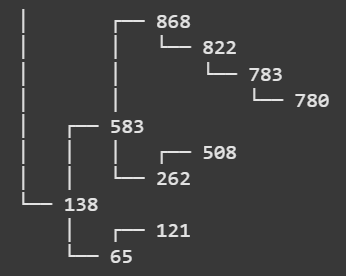

* K = 65 --> (-1,121)
* K = 583 --> (508,780)

In [ ]:
def e1():
  ...

# Ejercicio 2

* Cree una función que reciba un árbol binario y una lista de identificadores a eliminar. En este árbol binario, identificaremos a cada hoja con un número desde 1 hasta N, siendo N la cantidad total de hojas que tiene el árbol. Esta identificación iniciará de izquierda a derecha, es decir, la hoja más a la izquierda del árbol será la hoja número 1 y la que se encuentra más a la derecha será la hoja número N. La función deberá eliminar las hojas cuyos identificadores estén en la lista de identificadores a eliminar.

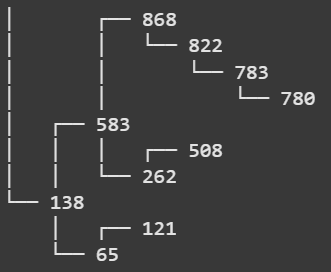

Por ejemplo, dado este árbol y una lista de identificadores a eliminar L = [1,8,9,15], sólo se debería eliminar el 121 ya que el identificador 1 es el único identificador que se puede asociar a una hoja existente.

In [ ]:
def e2():
  ...

# Ejercicio 3

* Dado un árbol general, devuelva una lista con todas las ramas (raíz a hoja) que no contengan valores repetidos. Por ejemplo, dado este árbol:

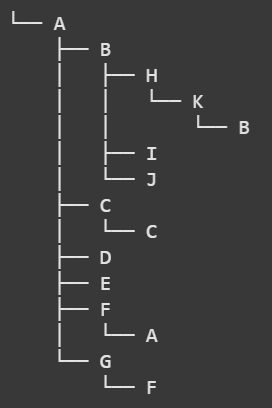

La respuesta sería:

* [["A","I"],["A","J"],["A","D"],["A","E"],["A","G","F"]]

In [ ]:
def e3():
  ...